# Boosting Techniques | Assignment

####**Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.**

**Soln:** Boosting is an ensemble machine learning technique that converts multiple weak learners (models slightly better than random chance) into a single strong learner to improve predictive accuracy. It operates sequentially, where each new model attempts to correct the errors specifically focusing on misclassified data points of the previous models.

 It strengthens weak learners through the following process:

* Sequential Learning: Unlike parallel methods like Bagging, Boosting trains models in a sequence, where each model relies on the performance of the previous one.
* Adaptive Re-weighting: Misclassified data points from the previous learner are assigned higher weights (greater importance). The next weak learner is then forced to focus on these "hard" cases to correct them.
* Weighted Voting/Aggregation: In the final step, all weak learners are combined to form a strong learner, usually using a weighted majority vote (for classification) or weighted average (for regression), where more accurate models have higher influence.

#### **Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?**

**Soln:** AdaBoost increases the weights of misclassified data points to focus on them in the next iteration, while Gradient Boosting fits new models to the residual errors (the difference between predicted and actual values) of the previous model using gradient descent.

* Error Correction Mechanism: AdaBoost tweaks sample weights, putting more emphasis on hard-to-classify points. Gradient Boosting directly calculates the gradient (direction) of the loss function to minimize errors.
* Sequential Learning: AdaBoost fits a sequence of weak learners (typically decision stumps) by modifying data weights. Gradient Boosting builds models sequentially to minimize loss, typically using more complex weak learners (shallow decision trees).
* Loss Function Handling: AdaBoost traditionally minimizes exponential loss. Gradient Boosting is more flexible, allowing the optimization of any differentiable loss function (e.g., mean squared error).
Sensitivity to Noise:

####**Question 3: How does regularization help in XGBoost?**

**Soln:** write in one para
Regularization helps XGBoost prevent overfitting by adding penalty terms for model complexity directly into its objective function. It uses L1 (alpha) and L2 (lambda) regularization to shrink leaf weights, which reduces the model's sensitivity to noise and can even eliminate unimportant features. Additionally, the gamma (gamma) parameter sets a minimum gain threshold for new splits, acting as a pruning mechanism that ensures trees only grow when they provide significant predictive value. Together with constraints like learning rate and tree depth, these features force the model to learn more conservative, generalized patterns that perform better on unseen data.

#### **Question 4: Why is CatBoost considered efficient for handling categorical data?**

**Soln:** CatBoost is highly efficient because it processes categorical variables natively through a technique called Ordered Target Encoding, which converts categories into numerical values using a randomized permutation approach that prevents data leakage and overfitting. Unlike other algorithms that require manual preprocessing like one-hot encoding, CatBoost automatically identifies and creates feature combinations (e.g., combining "City" and "Job Type") to capture complex relationships during training. Its use of oblivious (symmetric) trees further enhances efficiency, providing a balanced structure that allows for incredibly fast inference speeds and better generalization on datasets with high-cardinality features.

#### **Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?**

**Soln:** Boosting techniques (like XGBoost and LightGBM) are preferred over bagging (like Random Forest) in applications where achieving the highest possible predictive accuracy is more critical than computational speed or model simplicity. Because boosting iteratively corrects errors to reduce bias, it excels in complex, structured data environments such as:
* Search Engine Ranking: Algorithms like LambdaMART use boosting to order search results based on intricate user relevance signals.
Ad Click Prediction: High-precision tasks in digital advertising use boosting to capture subtle non-linear patterns that indicate whether a user will click an ad.
* High-Stakes Fraud Detection: While bagging is robust to noise, boosting is often preferred for pinpointing hard to classify fraudulent transactions by focusing heavily on previously misclassified cases.
* Kaggle & Competitive Data Science: Boosting is the "gold standard" for tabular data competitions where winning margins depend on capturing every bit of signal from the features.
* Personalised Recommendation Systems: E-commerce companies use boosting to refine customer dropout predictions and tailor product suggestions based on sequential user behaviour.


#### Datasets:
* Use sklearn.datasets.load_breast_cancer() for classification tasks.
* Use sklearn.datasets.fetch_california_housing() for regression
tasks.

**Question 6: Write a Python program to:**
* Train an AdaBoost Classifier on the Breast Cancer dataset
* Print the model accuracy

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")


Model Accuracy: 0.9649


**Question 7: Write a Python program to:**
* Train a Gradient Boosting Regressor on the California Housing dataset
* Evaluate performance using R-squared score

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

housing = fetch_california_housing()
X, y = housing.data, housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")


R-squared Score: 0.7756


**Question 8: Write a Python program to:**
* Train an XGBoost Classifier on the Breast Cancer dataset
* Tune the learning rate using GridSearchCV
* Print the best parameters and accuracy



In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Best Parameters: {best_params}")
print(f"Model Accuracy: {accuracy:.4f}")


Best Parameters: {'learning_rate': 0.2}
Model Accuracy: 0.9561


**Question 9: Write a Python program to:**
* Train a CatBoost Classifier
* Plot the confusion matrix using seaborn

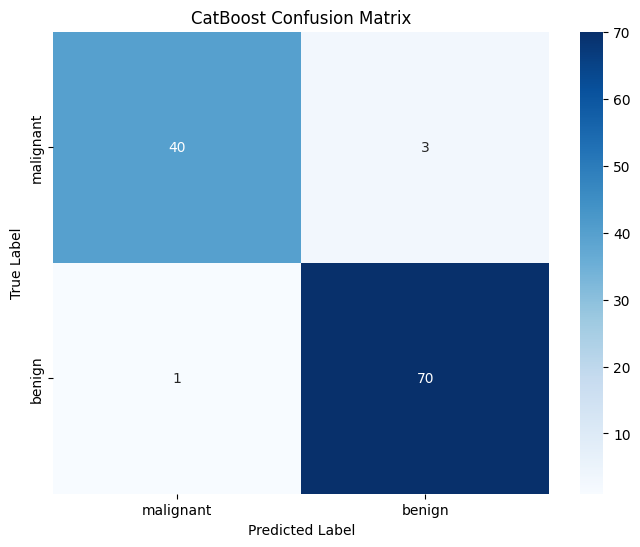

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier

# 1. Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the CatBoost Classifier (silent=True hides iteration logs)
model = CatBoostClassifier(iterations=100, silent=True, random_state=42)
model.fit(X_train, y_train)

# 4. Generate predictions and confusion matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 5. Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CatBoost Confusion Matrix')
plt.show()


#### **Question 10: You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior. The dataset is imbalanced, contains missing values, and has both numeric and categorical features. Describe your step-by-step data science pipeline using boosting techniques:**
* Data preprocessing & handling missing/categorical values
* Choice between AdaBoost, XGBoost, or CatBoost
* Hyperparameter tuning strategy
* Evaluation metrics you'd choose and why
* How the business would benefit from your model

**Soln:**
1. **Data Preprocessing & Handling Values
Missing Values:**   Since most modern boosting algorithms (XGBoost/CatBoost) handle missing values natively by learning the best direction for them during tree splits, I would leave them as-is to preserve information rather than using simple imputation (like mean/median).
Categorical Features: I would use Target Encoding or leave them for native handling. For transaction behavior (which often has high-cardinality features like "Merchant ID"), I would avoid one-hot encoding to prevent a massive increase in dimensionality.
2. **Model Choice:** CatBoost
I would choose CatBoost for this FinTech use case. It is superior for tabular datasets with a mix of categorical and numeric features because it uses Ordered Boosting to prevent target leakage and handles categorical data natively without manual preprocessing. It also tends to perform exceptionally well "out of the box" compared to XGBoost or AdaBoost.
3. **Hyperparameter Tuning Strategy :**
I would use a Bayesian Optimization approach (via libraries like Optuna) rather than a Grid Search. This is more efficient for large parameter spaces. I would focus on:
learning_rate and iterations (n_estimators).
depth (to control complexity).
l2_leaf_reg (to prevent overfitting on noisy transaction data).
scale_pos_weight (crucial for handling the imbalanced nature of default data).

4. **Evaluation Metrics :**
Standard accuracy is misleading for imbalanced default data (where most people don't default). I would choose:
PR-AUC (Precision-Recall Area Under Curve): Better than ROC-AUC for imbalanced sets as it focuses on the performance of the minority class (defaulters).
F1-Score: To balance the trade-off between Precision (avoiding false alarms) and Recall (catching all defaults).
Profit-weighted Loss: Assigning higher costs to "False Negatives" (missing a defaulter) than "False Positives" (denying a good customer).

5. **Business Benefit :**
The model provides a direct financial impact by:
Reducing Credit Risk: Identifying high-risk applicants before the loan is issued, saving the company from capital loss.
Operational Efficiency: Automating the approval process for low-risk customers, allowing the credit team to focus only on borderline cases.
Personalization: Enabling the company to offer better interest rates to customers with low default probabilities, improving customer retention.
